# Transfer Learning with Fashion-MNIST

In this exercise you will use *transfer learning* to adapt the CNN from the [Keras CNN session](../sessions/K_CNN.ipynb) to the Fashion-MNIST dataset.

This dataset contains 60,000 28x28 grayscale images of 10 fashion categories, together with a test set of 10,000 images.
The class labels are:

| Label | Description |
|---|---|
| 0 | T-shirt/top |
| 1 | Trouser |
| 2 | Pullover |
| 3 | Dress |
| 4 | Coat |
| 5 | Sandal |
| 6 | Shirt |
| 7 | Sneaker |
| 8 | Bag |
| 9 | Ankle boot |

The goal is to start from a model that already knows how to classify MNIST digits and fine-tune it on Fashion-MNIST.


In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import jax
import keras
print('Keras:', keras.__version__, 'backend:', keras.backend.backend(), jax.default_backend())


Keras: 3.11.2 backend: jax cpu


Load the Fashion-MNIST data, normalize the pixel values, and one-hot encode the labels.


In [2]:
(x_train, y_train), (x_test, y_test) = keras.datasets.fashion_mnist.load_data()
x_train = x_train.astype('float32')
x_test = x_test.astype('float32')
x_train /= 255
x_test /= 255

y_train = keras.utils.to_categorical(y_train)
y_test = keras.utils.to_categorical(y_test)
num_classes = y_test.shape[1]


Let's look at one training image.


[0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]


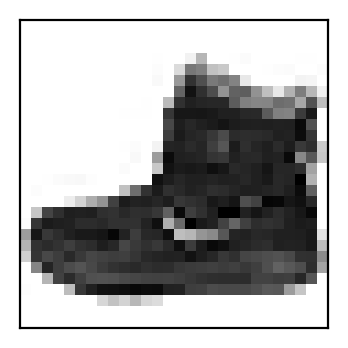

In [3]:
i = 0
plt.figure(figsize=(2, 2))
plt.imshow(x_train[i], cmap='gray_r')
plt.xticks([])
plt.yticks([])
print(y_train[i])


Load the CNN model we trained on MNIST in the [K_CNN session](../sessions/K_CNN.ipynb).


In [4]:
model = keras.models.load_model('../data/keras_cnn_model.keras')
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ reshape_2 (Reshape)             │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 24, 24, 32)     │           832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 12, 12, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 8, 8, 64)       │        51,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 4, 4, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1024)           │     1,049,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │        10,250 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,335,840 (12.73 MB)

 Trainable params: 1,111,946 (4.24 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2,223,894 (8.48 MB)

# Exercise

Re-train the model on Fashion-MNIST.

Store the returned history in a variable called `history`.


Epoch 1/5
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.8375 - loss: 0.4560 - val_accuracy: 0.8739 - val_loss: 0.3455
Epoch 2/5
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.8885 - loss: 0.3022 - val_accuracy: 0.8875 - val_loss: 0.3086
Epoch 3/5
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.9029 - loss: 0.2614 - val_accuracy: 0.8944 - val_loss: 0.2860
Epoch 4/5
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.9119 - loss: 0.2352 - val_accuracy: 0.9017 - val_loss: 0.2770
Epoch 5/5
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.9199 - loss: 0.2132 - val_accuracy: 0.8959 - val_loss: 0.2832


Save the re-trained model and evaluate it on the test set.


Test loss: 0.2831849455833435
Test accuracy: 0.8959000110626221


When starting from fresh random weights, the Fashion-MNIST CNN in [the CNN exercise](CNN.ipynb) learns more slowly.
Compare the accuracy you get here to the accuracy you get when training from scratch.


# Colophon
This notebook was written by [Yoav Ram](http://python.yoavram.com).

This work is licensed under a [CC BY-SA 4.0](https://creativecommons.org/licenses/by-sa/4.0/) International License.

![Python logo](https://www.python.org/static/community_logos/python-logo.png)
